Maintenant, nous allons regarder les modèles d'IA pour la prédiction des retards.
Nous allons utiliser scikit-learn.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import joblib

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Cible
target = "Average delay of all trains at arrival"
y = pd.to_numeric(df[target], errors="coerce")

# Feature retenue
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Encoder les catégorielles
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# Supprimer les lignes incomplètes
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

Notre modèle doit être entraîné puis testé. On définit la part du CSV dédiée au test : ici 0,2, soit 20 %.

In [2]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


On définit un premier modèle (régression linéaire) pour établir un point de référence.

In [3]:
# Modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.40
MSE  : 14.39
R²   : 0.2208


On obtient trois indicateurs :
MAE : erreur absolue moyenne (ex. 1,64 min d'erreur moyenne).
MSE : erreur quadratique moyenne (pénalise davantage les grosses erreurs).
R² : entre 0 et 1 ; plus c'est proche de 1, plus le modèle est pertinent. Ici il est peu performant, testons d'autres modèles.

In [4]:
# Modèle
model = MLPRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.45
MSE  : 15.27
R²   : 0.1733


In [5]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.65
MSE  : 24.05
R²   : -0.3020


In [6]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


MAE : 2.38
MSE  : 13.84
R²   : 0.2505


In [7]:
# Modèle
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 2.01
MSE  : 11.62
R²   : 0.3706


Pour l'instant, le `RandomForestRegressor` est le plus performant avec un $R^2$ de 0,31.

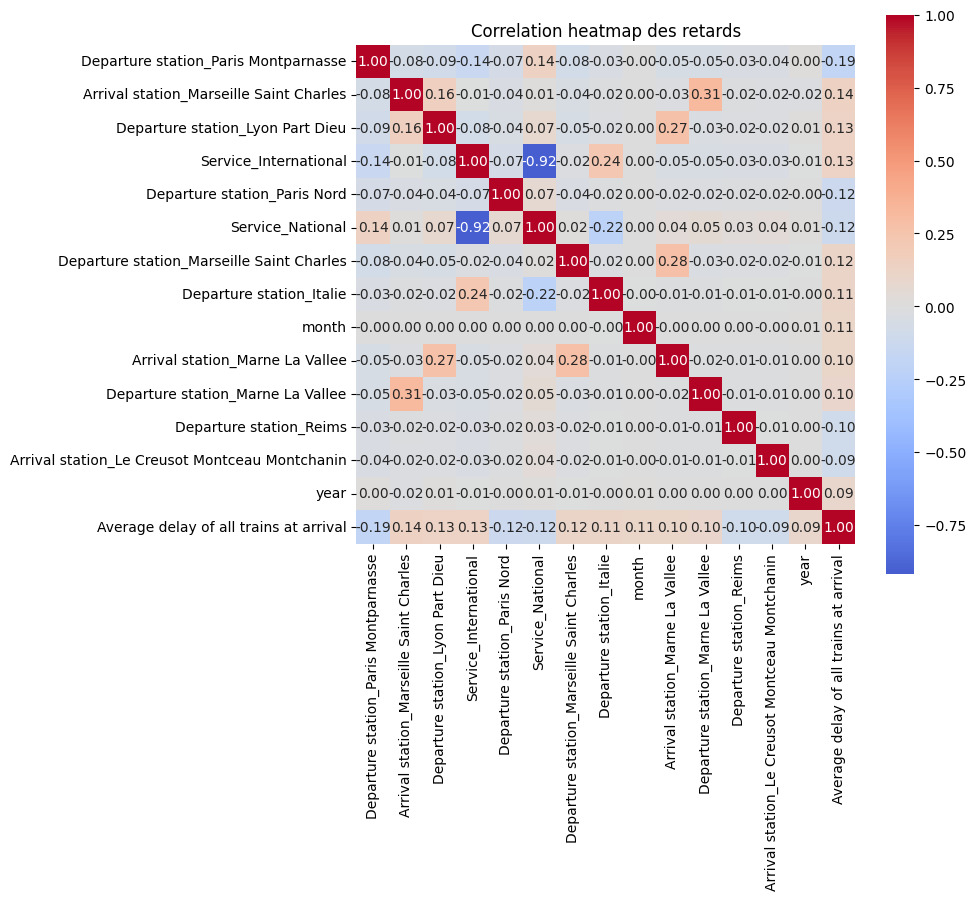

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation sur les features utilisees par le modele
corr_to_target = X.apply(lambda col: col.corr(y, method="spearman"))

# Garder les facteurs les plus corrélés pour une heatmap lisible
top_features = corr_to_target.abs().sort_values(ascending=False).head(14).index

corr_top = pd.concat([X[top_features], y], axis=1).corr(method="spearman")

plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_top,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation heatmap des retards")
plt.tight_layout()
plt.show()

Nous avons évalué des modèles via scikit-learn.
Passons à XGBoost pour créer notre propre modèle avec des variables spécifiques, puis comparer ses résultats au meilleur modèle scikit-learn.

In [9]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Cible
target = "Average delay of all trains at arrival"
y = pd.to_numeric(df[target], errors="coerce")

# Feature retenue
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Encoder les catégorielles
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# Supprimer les lignes incomplètes
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parametre du modèle
model = xgb.XGBRegressor(
    n_estimators=10000,
    max_depth=8,
    learning_rate=0.001,
    random_state=42
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Sauvegarde en un seul fichier
joblib.dump({"model": model, "columns": X.columns.tolist()}, "model.pkl")
print("Modèle sauvegardé !")

RMSE : 3.54
MAE  : 2.12
R²   : 0.3232
Modèle sauvegardé !


Le modèle est légèrement plus performant : $R^2 = 0,32$ au lieu de 0,31 pour scikit-learn.

Nous utilisons maintenant le modèle d'IA pour prédire le retard moyen sur une ligne précise.

In [10]:
import joblib
import pandas as pd

# Charger le tout en un seul coup
saved = joblib.load("model.pkl")
model = saved["model"]
model_columns = saved["columns"]

# Remplissage
data = {
    "month": 12,
    "year": 2028,
    "day_of_week": 0,
    "is_peak_month": 0,
    "Service_National": 1,
    "Departure station_Bordeaux Saint Jean": 1,
    "Arrival station_Paris Montparnasse": 1,
}

X_input = pd.DataFrame([data], columns=model_columns).fillna(0)

prediction = model.predict(X_input)
print(f"Retard prédit : {prediction[0]:.1f} minutes")

Retard prédit : 7.7 minutes


On peut aussi tester d'autres prédictions, comme le pourcentage de chances d'annulation d'un train, en changeant les paramètres d'entrée.

In [13]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df = pd.read_csv("cleaned_dataset.csv", sep=";", on_bad_lines="skip")

# Feature engineering temporel
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_peak_month"] = df["month"].isin([7, 8, 12]).astype(int)
df = df.drop(columns=["Date"])

# Cible
target = "Number of cancelled trains"
y = pd.to_numeric(df[target], errors="coerce")

# Feature retenue
features = [
    "Departure station",
    "Arrival station",
    "Service",
    "month",
    "year",
    "day_of_week",
    "is_peak_month",
]

X = df[features]

# Encoder les catégorielles
X = pd.get_dummies(X, columns=["Service", "Departure station", "Arrival station"])

# Supprimer les lignes incomplètes
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle
model = xgb.XGBRegressor(
    n_estimators=10000,
    max_depth=6,
    learning_rate=0.001,
    random_state=42
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Sauvegarde en un seul fichier
joblib.dump({"model": model, "columns": X.columns.tolist()}, "src/Bonus/model_train_cancel.pkl")
print("Modèle sauvegardé !")

RMSE : 13.80
MAE  : 5.52
R²   : 0.6328
Modèle sauvegardé !


In [14]:
import joblib
import pandas as pd

# Charger le tout en un seul coup
saved = joblib.load("src/Bonus/model_train_cancel.pkl")
model = saved["model"]
model_columns = saved["columns"]

# Remplissage
data = {
    "month": 12,
    "year": 2028,
    "day_of_week": 0,
    "is_peak_month": 0,
    "Service_National": 1,
    "Departure station_Bordeaux Saint Jean": 1,
    "Arrival station_Paris Montparnasse": 1,
}

X_input = pd.DataFrame([data], columns=model_columns).fillna(0)

prediction = model.predict(X_input)
print(f"Pourcantage de chance d'un train annulé : {prediction[0]:.1f} %")

Pourcantage de chance d'un train annulé : 11.0 %
